## Phase 3 — Rule-Based Segmentation + Cohort Retention

Dataset: credit_users (30,000 users)

### Segments:
- 🔴 High Risk   → frequent payment delays + pays very little
- 🟠 Medium Risk → some delays, inconsistent payments  
- 🟡 Low Risk    → rare delays, mostly pays on time
- 🟢 Loyal       → no delays, always pays in full

In [19]:
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [21]:
df.shape

(30000, 25)

In [22]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [23]:
df.columns = df.columns.str.lower().str.replace('.', '_', regex=False)
print(df.columns.tolist())

['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_payment_next_month']


### Delay score

In [24]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['delay_score'] = df[pay_cols].apply(
    lambda row: sum(1 for val in row if val > 0), axis=1
)

print(df['delay_score'].value_counts().sort_index())

delay_score
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64


In [25]:
bill_cols = ['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6']
pay_cols_amt = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

df['total_billed'] = df[bill_cols].sum(axis=1)
df['total_paid']   = df[pay_cols_amt].sum(axis=1)

# Ratio — how much they paid vs how much they owed
# We clip at 1.0 because some people overpay (ratio > 1 doesn't mean anything extra)
df['repayment_ratio'] = (df['total_paid'] / df['total_billed']).clip(upper=1.0)

# Users with zero billing get ratio 0 — they had no activity
df['repayment_ratio'] = df['repayment_ratio'].fillna(0)

print(df['repayment_ratio'].describe().round(3))

count    30000.000
mean         0.226
std          5.350
min       -546.929
25%          0.041
50%          0.086
75%          0.598
max          1.000
Name: repayment_ratio, dtype: float64


In [26]:
df['repayment_ratio'] = df['repayment_ratio'].clip(lower=0, upper=1.0)

print(df['repayment_ratio'].describe().round(3))

count    30000.000
mean         0.314
std          0.367
min          0.000
25%          0.041
50%          0.086
75%          0.598
max          1.000
Name: repayment_ratio, dtype: float64


Median repayment ratio is only 0.086 — meaning half users pay back less than 9% of what they owe each month. 

### 4 segments

The rules:

- Delayed 4+ months OR pays back less than 5% → High Risk
- Delayed 2-3 months OR pays back less than 15% → Medium Risk
- Delayed 1 month OR pays back less than 50% → Low Risk
- Everything else (no delays, pays back 50%+) → Loyal

In [27]:
def assign_segment(row):
    delay = row['delay_score']
    ratio = row['repayment_ratio']

    if delay >= 4 or ratio < 0.05:
        return 'High Risk'
    elif delay >= 2 or ratio < 0.15:
        return 'Medium Risk'
    elif delay == 1 or ratio < 0.50:
        return 'Low Risk'
    else:
        return 'Loyal'

df['segment'] = df.apply(assign_segment, axis=1)

print(df['segment'].value_counts())

segment
High Risk      11716
Medium Risk     6663
Loyal           6355
Low Risk        5266
Name: count, dtype: int64


In [28]:
print(df.groupby('segment')[['delay_score', 'repayment_ratio']].mean().round(3))

             delay_score  repayment_ratio
segment                                  
High Risk          1.530            0.041
Low Risk           0.393            0.471
Loyal              0.000            0.868
Medium Risk        0.755            0.140


- Loyal: 0 delays, pays back 86% ✅
- Low Risk: rare delays, pays back 47% ✅
- Medium Risk: some delays, pays back 14% ✅
- High Risk: frequent delays, pays back only 4% ✅

**High Risk users pay back only 4%** of what they owe on average, 
   vs 86% for Loyal users — a 21x difference in repayment behaviour.

### Segment distribution chart

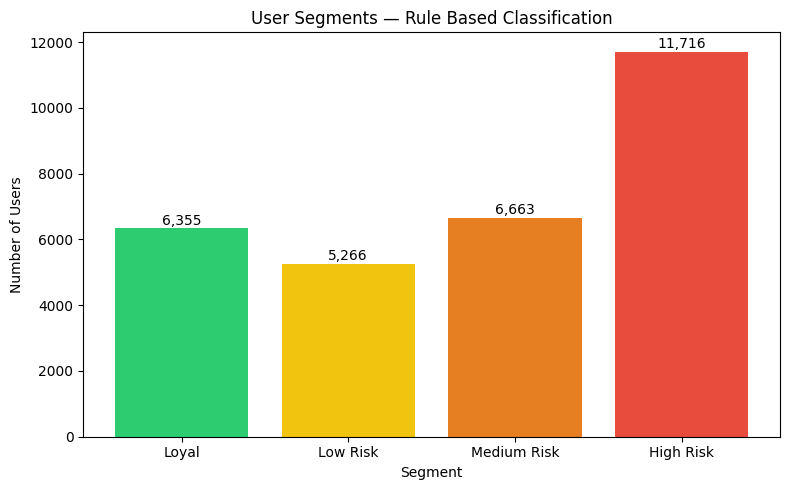

In [29]:
seg_counts = df['segment'].value_counts().reindex(['Loyal', 'Low Risk', 'Medium Risk', 'High Risk'])

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(seg_counts.index, seg_counts.values, color=colors)
plt.title('User Segments — Rule Based Classification')
plt.xlabel('Segment')
plt.ylabel('Number of Users')

for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

 **39% of users are High Risk** — 11,716 users show frequent payment 
   delays and low repayment. This is the primary target for early 
   intervention by the bank.

### Default rate per segment

In [30]:
default_by_seg = df.groupby('segment')['default_payment_next_month'].mean().mul(100).round(2)
default_by_seg = default_by_seg.reindex(['Loyal', 'Low Risk', 'Medium Risk', 'High Risk'])
print(default_by_seg)

segment
Loyal          12.18
Low Risk       15.19
Medium Risk    21.87
High Risk      30.77
Name: default_payment_next_month, dtype: float64


 Default rate rises cleanly from Loyal to High Risk.
- Loyal → 12% default rate
- Low Risk → 15%
- Medium Risk → 22%
- High Risk → 31%
 

**Even Loyal users default at 12%** — no segment is completely safe, 
   suggesting external factors (job loss, emergencies) affect even 
   disciplined payers.

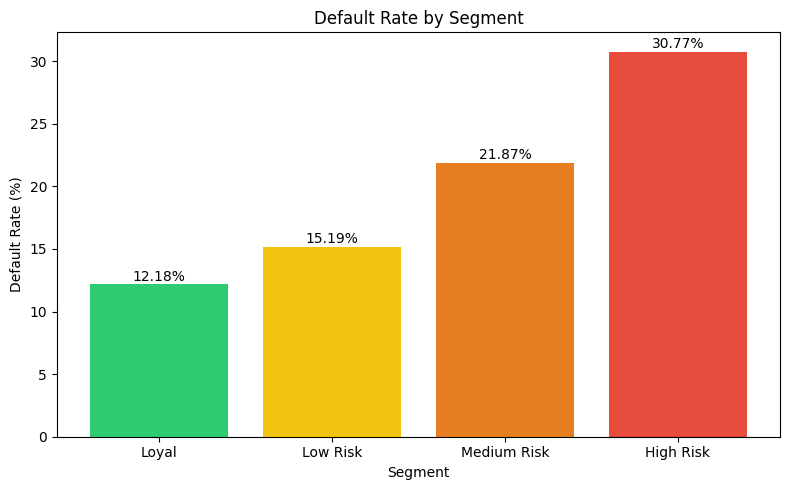

In [31]:
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(default_by_seg.index, default_by_seg.values, color=colors)
plt.title('Default Rate by Segment')
plt.xlabel('Segment')
plt.ylabel('Default Rate (%)')

for bar, val in zip(bars, default_by_seg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Segmentation is validated** — default rate rises consistently from 
   12% (Loyal) to 31% (High Risk), confirming the rules correctly 
   separate risky from healthy users.

## Cohort Retention
Across 6 months, how many users were still paying on time each month?

- pay_6 → oldest month (6 months ago)
- pay_5 → 5 months ago
- pay_4 → 4 months ago
- pay_3 → 3 months ago
- pay_2 → 2 months ago
- pay_0 → most recent month

In [32]:
# For each month, count users who were NOT delaying (value <= 0)
months = ['pay_6', 'pay_5', 'pay_4', 'pay_3', 'pay_2', 'pay_0']
labels = ['Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']

ontime_counts = []
for col in months:
    count = (df[col] <= 0).sum()
    ontime_counts.append(count)

retention_df = pd.DataFrame({
    'month': labels,
    'ontime_users': ontime_counts
})

retention_df['retention_pct'] = (retention_df['ontime_users'] / 30000 * 100).round(2)
retention_df['drop_pct'] = (retention_df['retention_pct'].shift(1) - retention_df['retention_pct']).round(2)

print(retention_df)

     month  ontime_users  retention_pct  drop_pct
0  Month 1         26921          89.74       NaN
1  Month 2         27032          90.11     -0.37
2  Month 3         26490          88.30      1.81
3  Month 4         25787          85.96      2.34
4  Month 5         25562          85.21      0.75
5  Month 6         23182          77.27      7.94


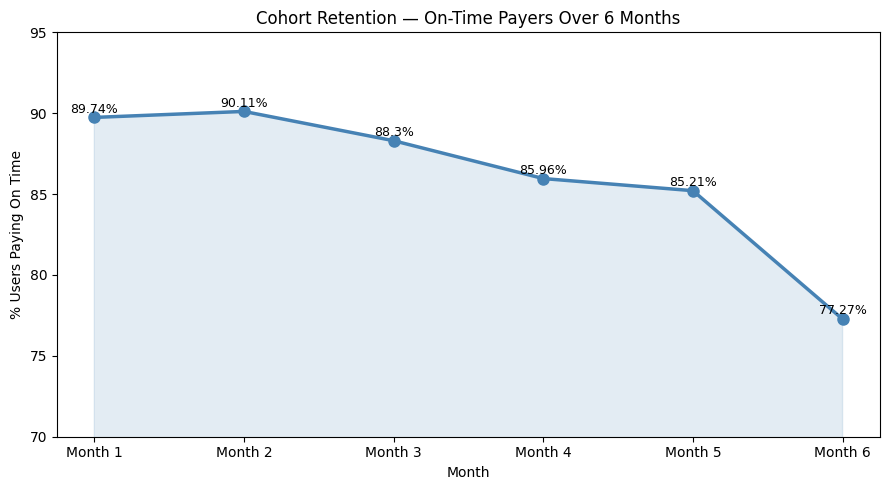

In [33]:
plt.figure(figsize=(9, 5))
plt.plot(retention_df['month'], retention_df['retention_pct'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=8)

# Shade the area under the curve
plt.fill_between(retention_df['month'], retention_df['retention_pct'], 
                 alpha=0.15, color='steelblue')

plt.title('Cohort Retention — On-Time Payers Over 6 Months')
plt.xlabel('Month')
plt.ylabel('% Users Paying On Time')
plt.ylim(70, 95)

# Add value labels on each point
for i, row in retention_df.iterrows():
    plt.text(i, row['retention_pct'] + 0.3, 
             f"{row['retention_pct']}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Overall retention dropped from 89.7% to 77.3% over 6 months**
— meaning 1 in 8 users who were paying on time eventually stopped.

Retention by segment

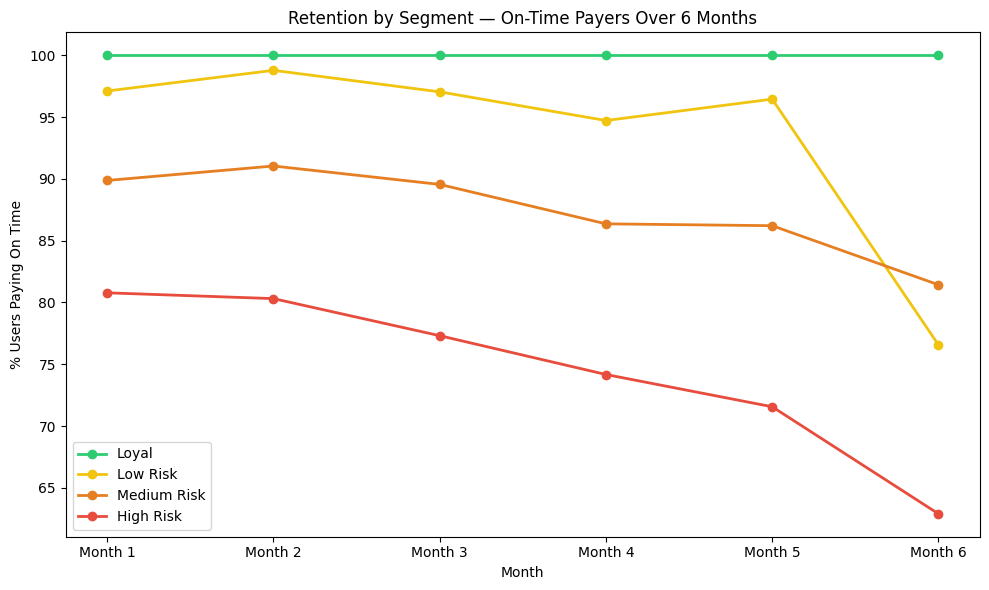

In [34]:
seg_retention = []

for col, label in zip(months, labels):
    for seg in ['Loyal', 'Low Risk', 'Medium Risk', 'High Risk']:
        seg_df = df[df['segment'] == seg]
        count = (seg_df[col] <= 0).sum()
        total = len(seg_df)
        seg_retention.append({
            'month': label,
            'segment': seg,
            'retention_pct': round(count / total * 100, 2)
        })

seg_ret_df = pd.DataFrame(seg_retention)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Loyal': '#2ecc71', 'Low Risk': '#f1c40f', 
          'Medium Risk': '#e67e22', 'High Risk': '#e74c3c'}

for seg in ['Loyal', 'Low Risk', 'Medium Risk', 'High Risk']:
    data = seg_ret_df[seg_ret_df['segment'] == seg]
    ax.plot(data['month'], data['retention_pct'], 
            marker='o', label=seg, color=colors[seg], linewidth=2)

ax.set_title('Retention by Segment — On-Time Payers Over 6 Months')
ax.set_xlabel('Month')
ax.set_ylabel('% Users Paying On Time')
ax.legend()
plt.tight_layout()
plt.show()


**By segment:**

| Segment | Month 1 | Month 6 | Total Drop |
|---|---|---|---|
| Loyal | 100% | 100% | 0% |
| Low Risk | 97.2% | 76.6% | 20.6% |
| Medium Risk | 89.9% | 81.4% | 8.5% |
| High Risk | 80.8% | 62.9% | 17.9% |

**Key findings:**

1. **Loyal users never slip** — 100% on-time rate across all 6 months,
   confirming the segmentation correctly identifies the healthiest users.

2. **High Risk users start bad and get worse** — already at 80.8% in 
   Month 1, dropping to 62.9% by Month 6. Nearly 1 in 3 High Risk 
   users is failing to pay on time by the final month.

3. **Low Risk users have a surprise cliff at Month 6** — stable for 5 
   months then sudden 20% drop. This suggests an external shock 
   (economic or seasonal) rather than gradual behavioural decline.

4. **Month 6 is the critical intervention point** — all segments except 
   Loyal show their sharpest drop in the most recent month, making it 
   the highest-priority period for bank outreach.

In [36]:
import os
os.makedirs("../exports", exist_ok=True)

# 1. Segmentation data
df[['id', 'limit_bal', 'age', 'education', 'default_payment_next_month',
    'delay_score', 'repayment_ratio', 'segment']].to_csv("../exports/user_segments.csv", index=False)

# 2. Segment summary
seg_summary = df.groupby('segment').agg(
    users=('id', 'count'),
    default_rate=('default_payment_next_month', 'mean')
).mul({'users': 1, 'default_rate': 100}).round(2).reset_index()
seg_summary.to_csv("../exports/segment_summary.csv", index=False)

# 3. Cohort retention overall
retention_df.to_csv("../exports/cohort_retention.csv", index=False)

# 4. Segment retention
seg_ret_df.to_csv("../exports/segment_retention.csv", index=False)

# 5. Funnel — recreate it here directly
funnel = pd.DataFrame([
    {'stage': '1. All users',         'users': 30000},
    {'stage': '2. Billed users',       'users': 29034},
    {'stage': '3. Paid at least once', 'users': 28568},
    {'stage': '4. Consistent payers',  'users': 26262},
    {'stage': '5. Loyal users',        'users': 23364},
])
funnel['drop_pct'] = ((funnel['users'].shift(1) - funnel['users']) / funnel['users'].shift(1) * 100).round(2)
funnel.to_csv("../exports/funnel.csv", index=False)

print("All exports done. Check your exports/ folder.")

All exports done. Check your exports/ folder.


In [45]:
months = ['pay_6', 'pay_5', 'pay_4', 'pay_3', 'pay_2', 'pay_0']

seg_retention = []
for i, (col, num) in enumerate(zip(months, range(1, 7)), 1):
    for seg in ['Loyal', 'Low Risk', 'Medium Risk', 'High Risk']:
        seg_df = df[df['segment'] == seg]
        count = (seg_df[col] <= 0).sum()
        total = len(seg_df)
        seg_retention.append({
            'month': f'M0{num}',
            'segment': seg,
            'retention_pct': round(count / total * 100, 2)
        })

seg_ret_df = pd.DataFrame(seg_retention)
seg_ret_df.to_csv("../exports/segment_retention.csv", index=False)
print(seg_ret_df['month'].unique())

['M01' 'M02' 'M03' 'M04' 'M05' 'M06']
